# Assignment 1: Simple Linear Regression — TV Advertising vs. Sales

**Objective:** Examine the relationship between TV advertising budget and Sales using simple linear regression.

Model: **Sales = β0 + β1·TV + ε**

Dataset: `tv_sales_data.csv` (TV budget in $1000s, Sales in 1000s of units)

Two approaches are used to fit the model and are compared at the end:
- **Approach 1: OLS (Ordinary Least Squares)** — the standard closed-form solution.
- **Approach 2: Gradient Descent** — an iterative optimization method that arrives at (approximately) the same coefficients.

## 1. Import the dataset

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = pd.read_csv("tv_sales_data.csv")
df

,TV,Sales
0,5,7
1,10,9
2,15,12
3,20,14
4,25,18
5,30,21


## 2. Approach 1: OLS (Ordinary Least Squares)

OLS finds the exact closed-form solution that minimizes the sum of squared residuals in one step — no iteration required.

In [2]:
X = sm.add_constant(df["TV"])   # adds the beta0 intercept term
y = df["Sales"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     377.0
Date:                Wed, 09 Sep 2026   Prob (F-statistic):           4.15e-05
Time:                        15:23:25   Log-Likelihood:                -4.3260
No. Observations:                   6   AIC:                             12.65
Df Residuals:                       4   BIC:                             12.24
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.6000      0.567      6.345      0.0

C:\Users\Aditya\AppData\Roaming\Python\Python314\site-packages\statsmodels\regression\linear_model.py:3158: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  omni, omnipv = cached("omni_normtest", lambda: omni_normtest(self.wresid))


### Extract the specific values requested by the assignment

In [3]:
beta0, beta1 = model.params["const"], model.params["TV"]
se_beta0, se_beta1 = model.bse["const"], model.bse["TV"]
p_beta0, p_beta1 = model.pvalues["const"], model.pvalues["TV"]
r_squared = model.rsquared

print(f"beta0 (intercept)      = {beta0:.4f}")
print(f"beta1 (slope, TV)      = {beta1:.4f}")
print(f"SE(beta0)              = {se_beta0:.4f}")
print(f"SE(beta1)              = {se_beta1:.4f}")
print(f"p-value (intercept)    = {p_beta0:.6f}")
print(f"p-value (slope)        = {p_beta1:.6e}")
print(f"R-squared              = {r_squared:.4f}")

beta0 (intercept)      = 3.6000
beta1 (slope, TV)      = 0.5657
SE(beta0)              = 0.5674
SE(beta1)              = 0.0291
p-value (intercept)    = 0.003160
p-value (slope)        = 4.148732e-05
R-squared              = 0.9895


## 3. Visualize the fit

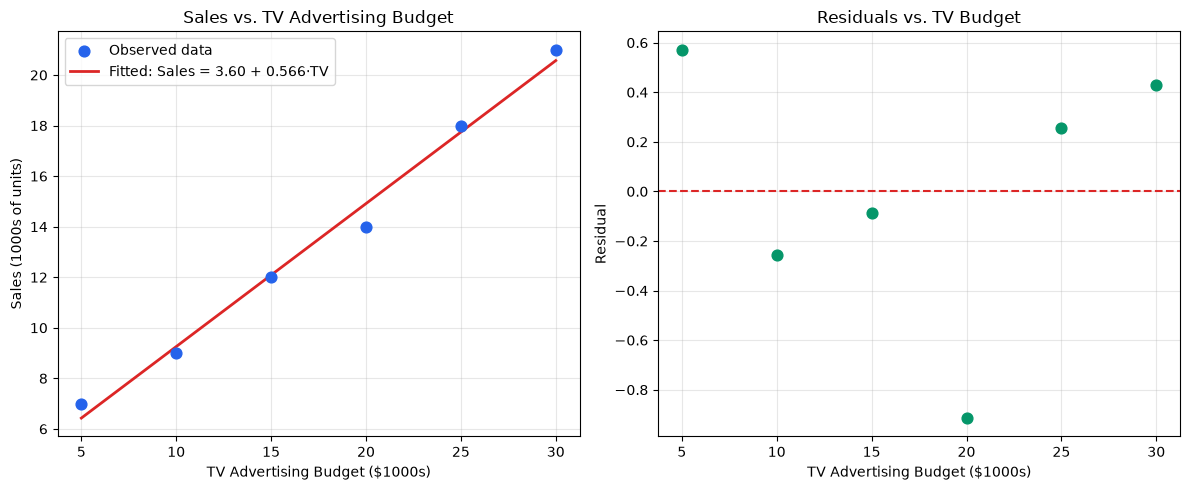

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot with fitted regression line
axes[0].scatter(df["TV"], df["Sales"], color="#2563eb", s=60, label="Observed data", zorder=3)
x_line = np.linspace(df["TV"].min(), df["TV"].max(), 100)
y_line = beta0 + beta1 * x_line
axes[0].plot(x_line, y_line, color="#dc2626", linewidth=2,
             label=f"Fitted: Sales = {beta0:.2f} + {beta1:.3f}·TV")
axes[0].set_xlabel("TV Advertising Budget ($1000s)")
axes[0].set_ylabel("Sales (1000s of units)")
axes[0].set_title("Sales vs. TV Advertising Budget")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residual plot
residuals = model.resid
axes[1].scatter(df["TV"], residuals, color="#059669", s=60, zorder=3)
axes[1].axhline(0, color="#dc2626", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("TV Advertising Budget ($1000s)")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs. TV Budget")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("regression_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Interpretation

**Sign and magnitude of β1:** β1 ≈ 0.5657 is positive, indicating that Sales increase as the TV
advertising budget increases. Concretely, each additional $1,000 spent on TV advertising is
associated with an increase of about 566 units sold (0.5657 thousand units), holding the
linear relationship fixed.

**Statistical significance:** The p-value for β1 is extremely small (≈ 4.15 × 10⁻⁵, well below
any conventional α such as 0.05 or 0.01). We therefore reject the null hypothesis H0: β1 = 0
and conclude there is strong, statistically significant evidence of a relationship between
TV advertising and sales. The intercept β0 is also statistically significant (p ≈ 0.0032),
though its practical interpretation (predicted sales at $0 TV budget) is more of a
mathematical baseline than a meaningful real-world scenario, since the observed data ranges
from $5,000-$30,000.

**Proportion of variance explained:** R² ≈ 0.9895, meaning about 98.95% of the variability in
Sales is explained by the linear relationship with TV advertising budget in this sample. Only
about 1.05% of the variance is left unexplained (residual/random variation). This is an
unusually high R² for real-world marketing data, which is expected here given the small,
clean, near-linear toy dataset (n = 6 points).

**Overall conclusion:** TV advertising budget is a strong, statistically significant, positive
predictor of sales in this dataset, and the fitted linear model explains nearly all of the
observed variation in sales.

## 5. Approach 2: Gradient Descent

Instead of solving for β0 and β1 in closed form, Gradient Descent starts with a guess
(β0 = β1 = 0) and repeatedly nudges both coefficients in the direction that reduces the
Mean Squared Error (MSE) cost function, using the learning rate `α` to control step size.
The features are standardized first purely for numerical stability during the iterations;
the learned coefficients are converted back to the original (unscaled) TV units at the end
so they can be compared directly to the OLS result above.

In [5]:
x = df["TV"].values.astype(float)
y_vals = df["Sales"].values.astype(float)
n = len(x)

# Standardize TV for stable gradient descent steps
x_mean, x_std = x.mean(), x.std()
x_scaled = (x - x_mean) / x_std

# Initialize coefficients (scaled space)
b0, b1 = 0.0, 0.0
alpha = 0.1          # learning rate
n_iters = 1000
history = []

for i in range(n_iters):
    y_pred = b0 + b1 * x_scaled
    error = y_pred - y_vals

    grad_b0 = (2 / n) * np.sum(error)
    grad_b1 = (2 / n) * np.sum(error * x_scaled)

    b0 -= alpha * grad_b0
    b1 -= alpha * grad_b1

    mse = np.mean(error ** 2)
    history.append(mse)

# Convert coefficients back from scaled space to original TV units
gd_beta1 = b1 / x_std
gd_beta0 = b0 - gd_beta1 * x_mean

print(f"Gradient Descent beta0 (intercept) = {gd_beta0:.4f}")
print(f"Gradient Descent beta1 (slope, TV) = {gd_beta1:.4f}")
print(f"Final MSE after {n_iters} iterations = {history[-1]:.6f}")

Gradient Descent beta0 (intercept) = 3.6000
Gradient Descent beta1 (slope, TV) = 0.5657
Final MSE after 1000 iterations = 0.247619


### Standard errors, R-squared, and p-values for the Gradient Descent fit

Gradient Descent itself only produces point estimates of β0 and β1 (it minimizes MSE, nothing more).
To get standard errors, R², and p-values *for this fit*, we apply the standard simple-linear-regression
inference formulas directly to the Gradient Descent coefficients and their residuals — not by reusing
the OLS `statsmodels` output.

For residuals $e_i = y_i - (\hat\beta_0 + \hat\beta_1 x_i)$, with $n$ observations and $S_{xx} = \sum (x_i - \bar x)^2$:

- Residual variance: $\hat\sigma^2 = \dfrac{\text{RSS}}{n-2}$, where $\text{RSS} = \sum e_i^2$
- $SE(\hat\beta_1) = \sqrt{\hat\sigma^2 / S_{xx}}$
- $SE(\hat\beta_0) = \sqrt{\hat\sigma^2 \left(\dfrac{1}{n} + \dfrac{\bar x^2}{S_{xx}}\right)}$
- $t = \hat\beta / SE(\hat\beta)$, compared against a t-distribution with $n-2$ degrees of freedom, to get the p-value
- $R^2 = 1 - \text{RSS}/\text{TSS}$, where $\text{TSS} = \sum (y_i - \bar y)^2$

In [ ]:
from scipy import stats

# Fitted values and residuals from the GRADIENT DESCENT coefficients
y_fit_gd = gd_beta0 + gd_beta1 * x
resid_gd = y_vals - y_fit_gd

RSS_gd = np.sum(resid_gd ** 2)
TSS_gd = np.sum((y_vals - y_vals.mean()) ** 2)
df_resid = n - 2
sigma2_gd = RSS_gd / df_resid
Sxx = np.sum((x - x_mean) ** 2)

se_gd_beta0 = np.sqrt(sigma2_gd * (1 / n + x_mean ** 2 / Sxx))
se_gd_beta1 = np.sqrt(sigma2_gd / Sxx)

t_gd_beta0 = gd_beta0 / se_gd_beta0
t_gd_beta1 = gd_beta1 / se_gd_beta1
p_gd_beta0 = 2 * (1 - stats.t.cdf(abs(t_gd_beta0), df_resid))
p_gd_beta1 = 2 * (1 - stats.t.cdf(abs(t_gd_beta1), df_resid))

r_squared_gd = 1 - RSS_gd / TSS_gd

print(f"beta0 (intercept, GD)   = {gd_beta0:.4f}")
print(f"beta1 (slope, GD)       = {gd_beta1:.4f}")
print(f"SE(beta0, GD)           = {se_gd_beta0:.4f}")
print(f"SE(beta1, GD)           = {se_gd_beta1:.4f}")
print(f"t-stat (beta0, GD)      = {t_gd_beta0:.4f}")
print(f"t-stat (beta1, GD)      = {t_gd_beta1:.4f}")
print(f"p-value (intercept, GD) = {p_gd_beta0:.6f}")
print(f"p-value (slope, GD)     = {p_gd_beta1:.6e}")
print(f"R-squared (GD)          = {r_squared_gd:.4f}")

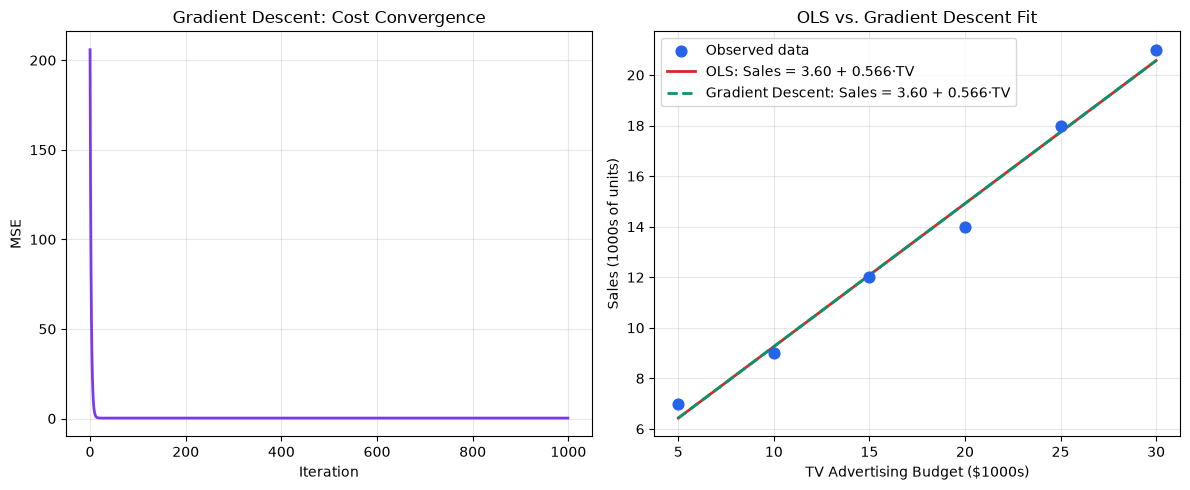

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Cost function convergence
axes[0].plot(range(n_iters), history, color="#7c3aed", linewidth=2)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE")
axes[0].set_title("Gradient Descent: Cost Convergence")
axes[0].grid(alpha=0.3)

# Both fitted lines over the data
axes[1].scatter(df["TV"], df["Sales"], color="#2563eb", s=60, label="Observed data", zorder=3)
x_line = np.linspace(df["TV"].min(), df["TV"].max(), 100)
axes[1].plot(x_line, beta0 + beta1 * x_line, color="#dc2626", linewidth=2,
             label=f"OLS: Sales = {beta0:.2f} + {beta1:.3f}·TV")
axes[1].plot(x_line, gd_beta0 + gd_beta1 * x_line, color="#059669", linewidth=2, linestyle="--",
             label=f"Gradient Descent: Sales = {gd_beta0:.2f} + {gd_beta1:.3f}·TV")
axes[1].set_xlabel("TV Advertising Budget ($1000s)")
axes[1].set_ylabel("Sales (1000s of units)")
axes[1].set_title("OLS vs. Gradient Descent Fit")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gradient_descent_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
comparison = pd.DataFrame({
    "Method": ["OLS", "Gradient Descent"],
    "beta0 (intercept)": [beta0, gd_beta0],
    "beta1 (slope, TV)": [beta1, gd_beta1],
})
comparison

,Method,beta0 (intercept),"beta1 (slope, TV)"
0,OLS,3.6,0.565714
1,Gradient Descent,3.6,0.565714


## 6. Comparison: OLS vs. Gradient Descent

Gradient Descent converges to essentially the same coefficients as OLS — as expected, since
both are minimizing the same squared-error cost function; OLS just solves for the minimum
directly instead of approaching it step by step.

**Why OLS is the practical choice here:** with a single predictor and only 6 data points, OLS
gives the exact answer instantly with no learning rate to tune and no risk of not converging.

**Why Gradient Descent is worth showing anyway:** it makes the optimization process visible —
the left plot above shows the MSE decreasing iteration by iteration, which is exactly what OLS
is solving for in one step. It's also the method that scales to problems where no closed-form
solution exists (e.g. regularized models, neural networks), so it's a useful concept to
demonstrate even on a dataset this small.